In [1]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# descargar el dataset

data = pd.read_csv(r'C:\Users\chuch\Documents\espy\modelos de clasificacion\publicidad.csv')
data.head()

,Tiempo_en_el_sitio,Edad,Ingresos_de_la_zona,Uso_de_Internet,Sexo,Clic_en_el_anuncio
0,68.95,35,61833.90,256.09,F,0
1,80.23,31,68441.85,193.77,M,0
2,69.47,26,59785.94,236.50,F,0
3,74.15,29,54806.18,245.89,M,0
4,68.37,35,73889.99,225.58,F,0


In [3]:
data.shape

(1000, 6)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tiempo_en_el_sitio   1000 non-null   float64
 1   Edad                 1000 non-null   int64  
 2   Ingresos_de_la_zona  1000 non-null   float64
 3   Uso_de_Internet      1000 non-null   float64
 4   Sexo                 1000 non-null   object 
 5   Clic_en_el_anuncio   1000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 47.0+ KB


In [5]:
# Checando los valores nulos
valores_nulos = data.isnull().sum()
print('Valores nulos en cada columna:\n', valores_nulos)

Valores nulos en cada columna:
 Tiempo_en_el_sitio     0
Edad                   0
Ingresos_de_la_zona    0
Uso_de_Internet        0
Sexo                   0
Clic_en_el_anuncio     0
dtype: int64


In [6]:
def fillna_cuantitativas(df):
    df = df.copy()  # evitar modificar el original
    
    cols_num = df.select_dtypes(include='number').columns
    
    df[cols_num] = df[cols_num].apply(lambda x: x.fillna(x.mean()))
    
    return df

In [7]:
data = fillna_cuantitativas(data)

In [8]:
# Drop duplicates si hay alguno
data.drop_duplicates(inplace=True)

In [9]:
#Checando el tipo de datos ahora de nuevo
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tiempo_en_el_sitio   1000 non-null   float64
 1   Edad                 1000 non-null   int64  
 2   Ingresos_de_la_zona  1000 non-null   float64
 3   Uso_de_Internet      1000 non-null   float64
 4   Sexo                 1000 non-null   object 
 5   Clic_en_el_anuncio   1000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 47.0+ KB


Exploracion de datos

In [10]:
data.describe()

,Tiempo_en_el_sitio,Edad,Ingresos_de_la_zona,Uso_de_Internet,Clic_en_el_anuncio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.00000


In [11]:
def resumen_estadistico (data, columnas='Cuantitativo'):
    
    """
    Calcula estadísticas descriptivas para múltiples columnas cuantitativas.
      Retorna:
    DataFrame con estadísticas descriptivas para cada columna especificada."""

    if columnas == 'Cuantitativo':
        columnas = data.select_dtypes(include=np.number).columns
    
    resumen = pd.DataFrame({
        'Media': data[columnas].mean(),
        'Mediana': data[columnas].median(),
        'Moda': data[columnas].mode().iloc[0] if not data[columnas].mode().empty else np.nan,
        'Min': data[columnas].min(),
        'Max': data[columnas].max(),
        'Varianza': data[columnas].var(),
        'Desv_Estandar': data[columnas].std(),
        'Q1_25%': data[columnas].quantile(0.25),
        'Q3_75%': data[columnas].quantile(0.75)
    })
    
    resumen['Rango'] = resumen['Max'] - resumen['Min']
    
    return resumen.round(4)

In [12]:
resumen_estadistico(data)

,Media,Mediana,Moda,Min,Max,Varianza,Desv_Estandar,Q1_25%,Q3_75%,Rango
Tiempo_en_el_sitio,65.0002,68.215,62.26,32.60,91.43,2.513371e+02,15.8536,51.3600,78.5475,58.83
Edad,36.0090,35.000,31.00,19.00,61.00,7.718610e+01,8.7856,29.0000,42.0000,42.00
Ingresos_de_la_zona,55000.0001,57012.300,13996.50,13996.50,79484.80,1.799524e+08,13414.6340,47031.8025,65470.6350,65488.30
Uso_de_Internet,180.0001,183.130,113.53,104.78,269.96,1.927415e+03,43.9023,138.8300,218.7925,165.18
Clic_en_el_anuncio,0.5000,0.500,0.00,0.00,1.00,2.503000e-01,0.5003,0.0000,1.0000,1.00


In [13]:
cov_matrix = data.cov(numeric_only= True)

print('La covarianza es: \n', cov_matrix)

La covarianza es: 
                      Tiempo_en_el_sitio          Edad  Ingresos_de_la_zona  \
Tiempo_en_el_sitio           251.337095    -46.174146         6.613081e+04   
Edad                         -46.174146     77.186105        -2.152093e+04   
Ingresos_de_la_zona        66130.810908 -21520.925797         1.799524e+08   
Uso_de_Internet              360.991883   -141.634816         1.987625e+05   
Clic_en_el_anuncio            -5.933143      2.164665        -3.195989e+03   

                     Uso_de_Internet  Clic_en_el_anuncio  
Tiempo_en_el_sitio        360.991883           -5.933143  
Edad                     -141.634816            2.164665  
Ingresos_de_la_zona    198762.531533        -3195.989159  
Uso_de_Internet          1927.415396          -17.274094  
Clic_en_el_anuncio        -17.274094            0.250250  


Relacion entre variables (correlacion)

In [14]:
import sklearn
# Cargar librerias

# Tratamiento de Datos

import pandas as pd
import numpy as np

#Graficos

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Preprocesamiento y Modelo

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

#Configuracion de nuestro visuales

plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

#Ignorar las advertencias de paquetes y sus actualizaciones
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Correlacion entre columnas numericas

def matriz_correlacion(corr_mat):
  """ Funcion para Convertir una matriz de correlacion en formato numerica """
  corr_mat = corr_mat.stack().reset_index()
  corr_mat.columns = ['variable 1','variable 2','Correlacion']
  corr_mat = corr_mat.loc[corr_mat['variable 1'] != corr_mat['variable 2'], :]
  corr_mat['Valor Absoluto'] = np.abs(corr_mat['Correlacion'])
  corr_mat = corr_mat.sort_values('Valor Absoluto', ascending = False)

  return(corr_mat)

corr_matrix = data.select_dtypes(include = ['float','int']).corr(method = 'pearson')
matriz_correlacion(corr_matrix).head(20)

,variable 1,variable 2,Correlacion,Valor Absoluto
23,Clic_en_el_anuncio,Uso_de_Internet,-0.786539,0.786539
19,Uso_de_Internet,Clic_en_el_anuncio,-0.786539,0.786539
4,Tiempo_en_el_sitio,Clic_en_el_anuncio,-0.748117,0.748117
20,Clic_en_el_anuncio,Tiempo_en_el_sitio,-0.748117,0.748117
3,Tiempo_en_el_sitio,Uso_de_Internet,0.518658,0.518658
15,Uso_de_Internet,Tiempo_en_el_sitio,0.518658,0.518658
21,Clic_en_el_anuncio,Edad,0.492531,0.492531
9,Edad,Clic_en_el_anuncio,0.492531,0.492531
22,Clic_en_el_anuncio,Ingresos_de_la_zona,-0.476255,0.476255
14,Ingresos_de_la_zona,Clic_en_el_anuncio,-0.476255,0.476255


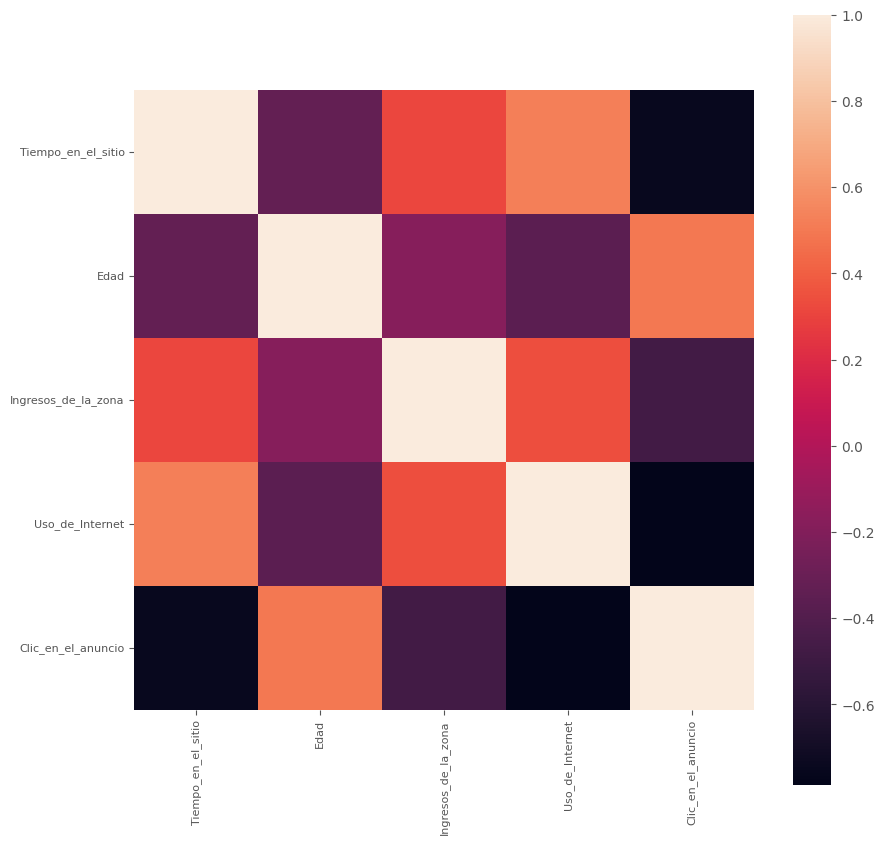

In [16]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,10))

sns.heatmap(
    corr_matrix,
    square = True,
    ax = ax)

ax.tick_params(labelsize = 8)

valores atipicos

In [17]:
data.columns

Index(['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet',
       'Sexo', 'Clic_en_el_anuncio'],
      dtype='object')

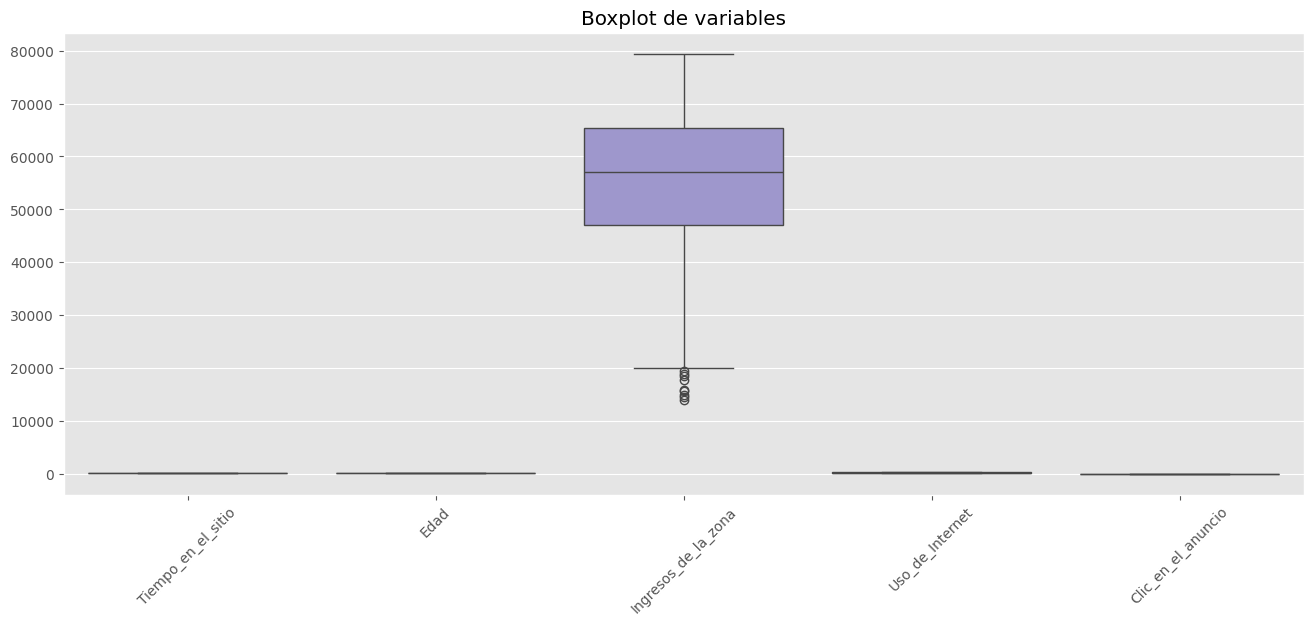

In [18]:
plt.figure(figsize=(16, 6))

sns.boxplot(data=data[['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet',
       'Sexo', 'Clic_en_el_anuncio']])

plt.title('Boxplot de variables')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Tiempo_en_el_sitio.quantile(0.75)-data.Tiempo_en_el_sitio.quantile(0.25)
limite_inferior_rainfall = data.Tiempo_en_el_sitio.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Tiempo_en_el_sitio.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Tiempo_en_el_sitio <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Tiempo_en_el_sitio <-30.2025 o > 160.11


In [20]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Ingresos_de_la_zona.quantile(0.75)-data.Ingresos_de_la_zona.quantile(0.25)
limite_inferior_rainfall = data.Ingresos_de_la_zona.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Ingresos_de_la_zona.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Ingresos_de_la_zona <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Ingresos_de_la_zona <-8284.694999999992 o > 120787.13249999998


In [21]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Edad.quantile(0.75)-data.Edad.quantile(0.25)
limite_inferior_rainfall = data.Edad.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Edad.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Edad <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Edad <-10.0 o > 81.0


In [22]:
# Vamos a buscar los valores atipicos para cada variable

IQR = data.Uso_de_Internet.quantile(0.75)-data.Uso_de_Internet.quantile(0.25)
limite_inferior_rainfall = data.Uso_de_Internet.quantile(0.25) - (IQR * 3)
limite_superior_rainfall = data.Uso_de_Internet.quantile(0.75) + (IQR * 3)

print('Los valores atipicos de Uso_de_Internet <{bajo} o > {alto}'.format(bajo = limite_inferior_rainfall, alto = limite_superior_rainfall))

Los valores atipicos de Uso_de_Internet <-101.05749999999992 o > 458.67999999999995


Prevalencia de clases:


,conteo,proporcion
Clase negativa (0: No clic),500,0.5
Clase positiva (1: Clic),500,0.5


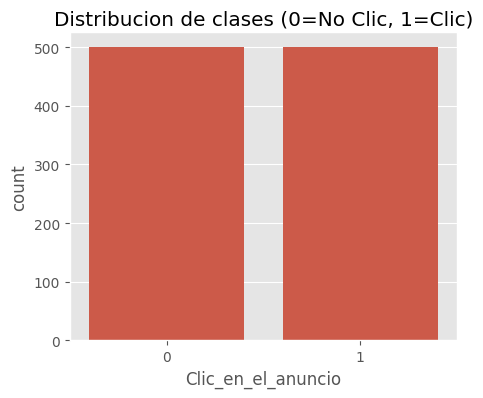

In [23]:
# Distribucion de clases (prevalencia)    #aqui hace un eda sencillo para conocer la proporcion de la clase positiva y negativa
conteo = data['Clic_en_el_anuncio'].value_counts().sort_index()
prevalencia = data['Clic_en_el_anuncio'].value_counts(normalize=True).sort_index()

resumen_clases = pd.DataFrame({
    'conteo': conteo,
    'proporcion': prevalencia
})
resumen_clases.index = ['Clase negativa (0: No clic)', 'Clase positiva (1: Clic)']    #hay un desvalanceo de clases

print('Prevalencia de clases:')
display(resumen_clases)

plt.figure(figsize=(5,4))
sns.countplot(x=data['Clic_en_el_anuncio'])
plt.title('Distribucion de clases (0=No Clic, 1=Clic)')
plt.show()

In [24]:
data.columns


Index(['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet',
       'Sexo', 'Clic_en_el_anuncio'],
      dtype='object')

Text(0, 0.5, 'clic_en_el_anuncio')

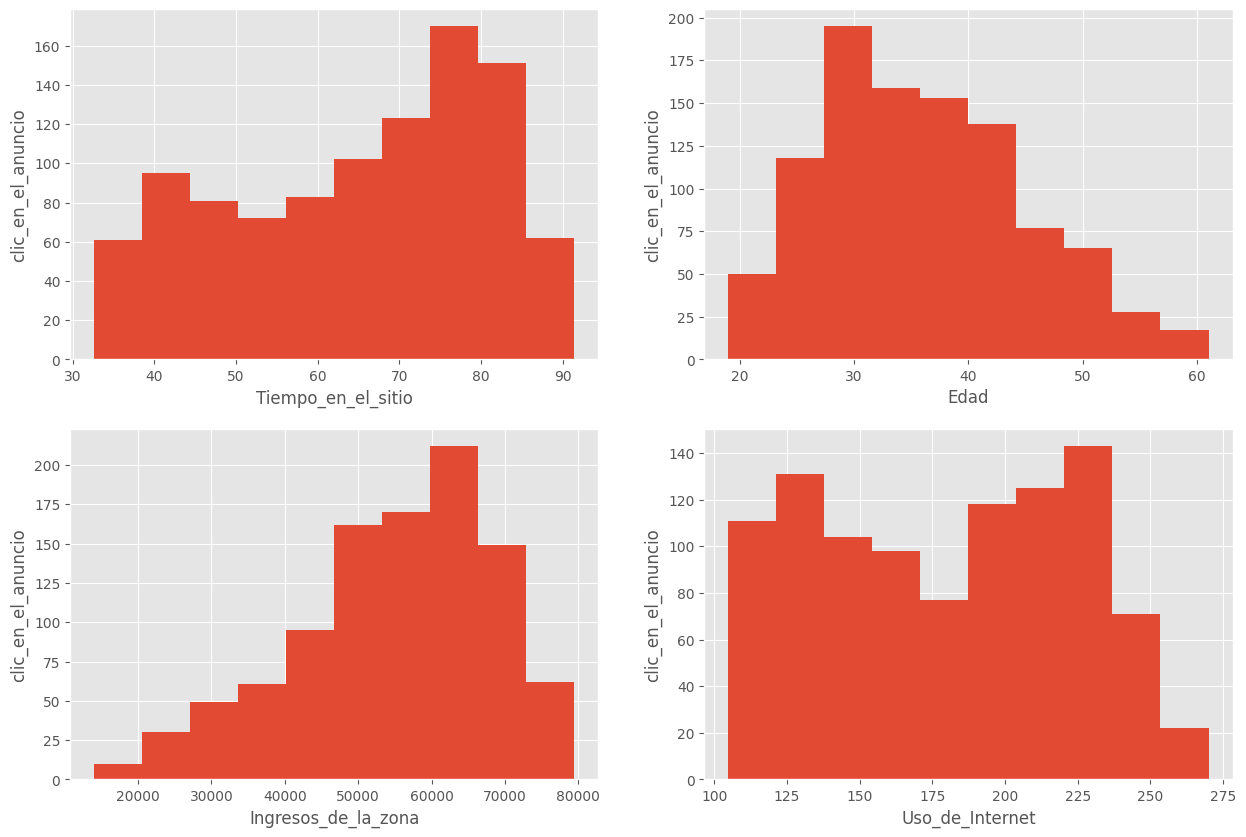

In [25]:
#Histograma

plt.figure(figsize = (15, 10))

plt.subplot(2,2,1)
fig = data.Tiempo_en_el_sitio.hist(bins=10)
fig.set_xlabel('Tiempo_en_el_sitio')
fig.set_ylabel('clic_en_el_anuncio')

plt.subplot(2,2,2)
fig = data.Edad.hist(bins=10)
fig.set_xlabel('Edad')
fig.set_ylabel('clic_en_el_anuncio')

plt.subplot(2,2,3)
fig = data.Ingresos_de_la_zona.hist(bins=10)
fig.set_xlabel('Ingresos_de_la_zona')
fig.set_ylabel('clic_en_el_anuncio')

plt.subplot(2,2,4)
fig = data.Uso_de_Internet.hist(bins=10)
fig.set_xlabel('Uso_de_Internet')
fig.set_ylabel('clic_en_el_anuncio')

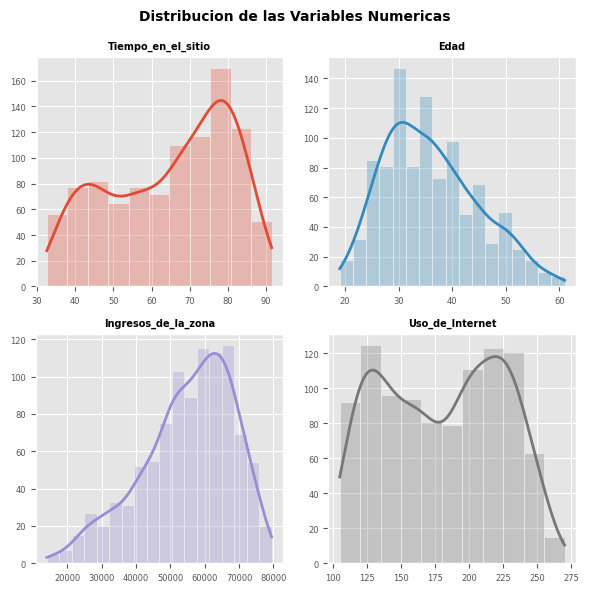

In [26]:
#Grafica de Distribucion para cada variable numerica

fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(6,6))
axes=axes.flat

columnas_numericas=data.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('Clic_en_el_anuncio')

for i,columna in enumerate(columnas_numericas):
  sns.histplot(
    data=data,
    x=columna,
    stat='count',
    kde=True,
    color=list(plt.rcParams['axes.prop_cycle']*2)[i]['color'],
    line_kws={'linewidth':2},
    alpha=0.3,
    ax=axes[i])

  axes[i].set_title(columna,fontsize=7,fontweight='bold')
  axes[i].tick_params(labelsize=6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Distribucion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()

IndexError: index 8 is out of bounds for axis 0 with size 4

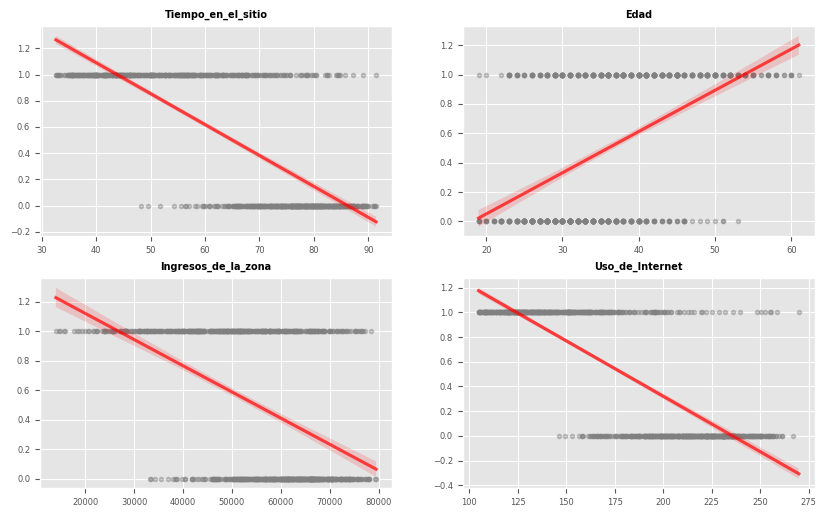

In [28]:
#Grafica de Dispersion para cada variable numerica y su relacion con la variable dependiente

fig,axes=plt.subplots(nrows=2,ncols=2,figsize=(10,6))
axes=axes.flat
columnas_numericas=data.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('Clic_en_el_anuncio')

for i,columna in enumerate(columnas_numericas):
  sns.regplot(
    data=data,
    x=data[columna],
    y='Clic_en_el_anuncio',
    color = 'gray',
    marker = '.',
    scatter_kws= {'alpha': 0.4},
    line_kws = {'color':'red', 'alpha':0.7},
    ax = axes[i])

  axes[i].set_title(columna,fontsize=7,fontweight='bold')
  axes[i].tick_params(labelsize=6)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

for i in [8]:
  fig.delaxes(axes[i])

fig.tight_layout()
plt.subplots_adjust(top=0.9)
plt.suptitle('Grafica de Dispersion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()

In [29]:
#Seleccionar las variables cualitativas

data.select_dtypes(include = 'object').head(10)

,Sexo
0,F
1,M
2,F
3,M
4,F
5,M
6,F
7,M
8,M
9,M


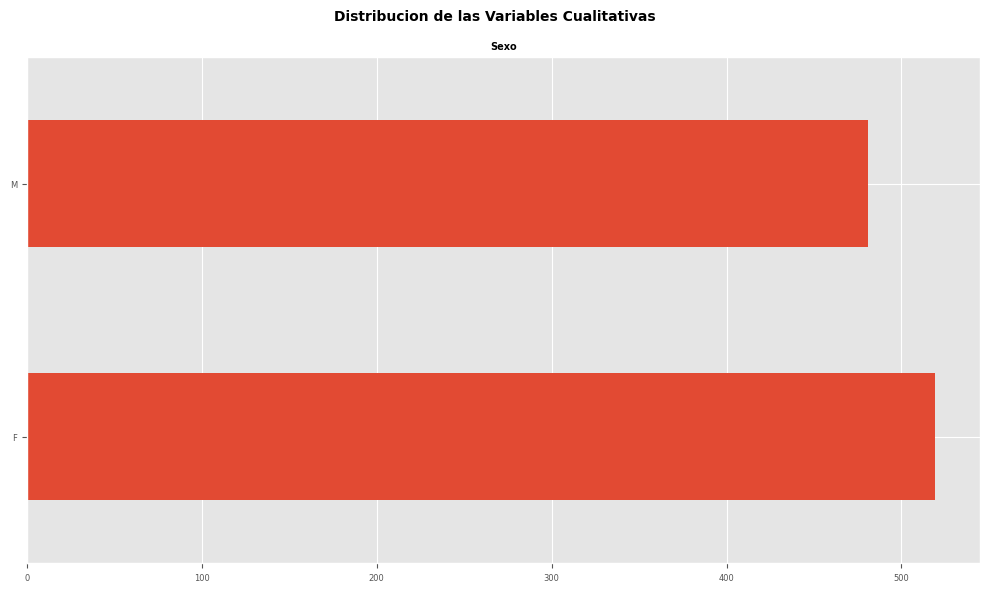

In [30]:
import numpy as np

columnas_cualitativas = data.select_dtypes(include='object').columns

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(columnas_cualitativas),
    figsize=(10,6)
)

# Convertir axes en iterable
axes = np.array(axes).flatten()

for i, columna in enumerate(columnas_cualitativas):
    data[columna].value_counts().plot(
        kind='barh',
        ax=axes[i]
    )

    axes[i].set_title(columna, fontsize=7, fontweight='bold')
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.9)

plt.suptitle(
    'Distribucion de las Variables Cualitativas',
    fontsize='medium',
    fontweight='bold'
)

plt.show()

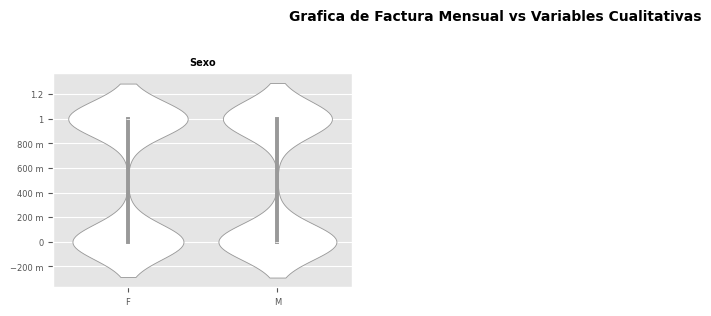

In [31]:
import numpy as np
import matplotlib.ticker as ticker
import seaborn as sns
import matplotlib.pyplot as plt

columnas_cualitativas = data.select_dtypes(include='object').columns

n = len(columnas_cualitativas)

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(10,8)
)

# Convertir axes en arreglo plano
axes = np.array(axes).flatten()

for i, columna in enumerate(columnas_cualitativas):

    sns.violinplot(
        data=data,
        x=columna,
        y='Clic_en_el_anuncio',
        color='white',
        ax=axes[i]
    )

    axes[i].set_title(columna, fontsize=7, fontweight='bold')
    axes[i].tick_params(labelsize=6)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].yaxis.set_major_formatter(ticker.EngFormatter())

# Eliminar subplots vacíos
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

plt.subplots_adjust(top=0.9)

plt.suptitle(
    'Grafica de Factura Mensual vs Variables Cualitativas',
    fontsize='medium',
    fontweight='bold'
)

plt.show()

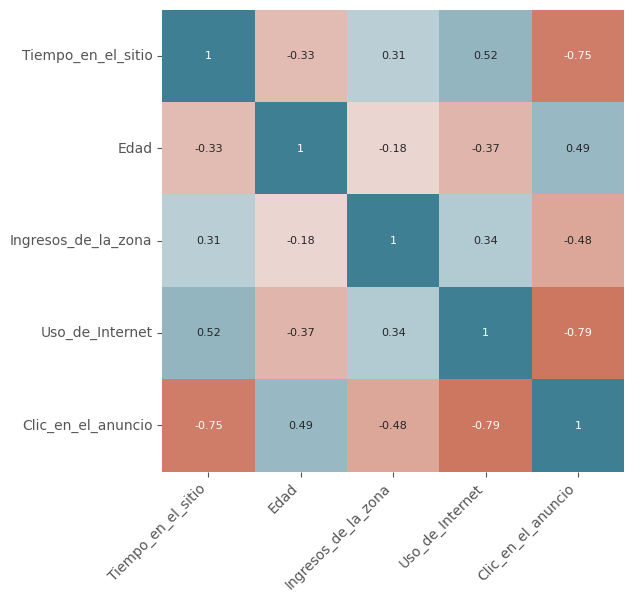

In [32]:
##HeatMap de Correlaciones

fig, axes = plt.subplots(nrows = 1, ncols =1, figsize = (6,6))

sns.heatmap(
    corr_matrix,
    cmap = sns.diverging_palette(20,220, n = 200),
    square = True,
    annot = True,
    center = 0,
    vmin = -1,
    vmax = 1,
    annot_kws = {'fontsize':8},
    cbar = False,
    ax = axes)

axes.set_xticklabels(axes.get_xticklabels(), rotation = 45, horizontalalignment = 'right')

plt.show()

In [33]:
X = data.drop(['Clic_en_el_anuncio'], axis = 1)

y = data['Clic_en_el_anuncio']

## Creación de Pipelines para tranformaciones automatizadas

In [34]:
#!pip install category_encoders

In [35]:
import numpy as np #algebra lineal
import pandas as pd #procesamiento datos
import matplotlib.pyplot as plt #Visualizacion de Datos
import seaborn as sns # Visualizaciones estadisticas
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler
from category_encoders import BinaryEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, roc_auc_score, log_loss, cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [36]:
def obtener_categoria(series):
  conteo_unico = series.nunique(dropna = True)
  conteo_total = series.notna().sum()

  if pd.api.types.is_numeric_dtype(series):
    return 'Cuantitativo'

  elif pd.api.types.is_datetime64_any_dtype(series):
    return 'Fecha'

  else:
    return 'Categoricas'


def print_categorias(data):
  for columna in data.columns:
    print(f'{columna}: {obtener_categoria(data[columna])}')

print_categorias(data)

Tiempo_en_el_sitio: Cuantitativo
Edad: Cuantitativo
Ingresos_de_la_zona: Cuantitativo
Uso_de_Internet: Cuantitativo
Sexo: Categoricas
Clic_en_el_anuncio: Cuantitativo


In [37]:
# Buscar las variables Categoricas

categoricas = [ var for var in data.columns if data[var].dtype == 'O']

print('La cantidad de variables categoricas son {} \n'.format(len(categoricas)))

print('Las variables categoricas son:', categoricas)

La cantidad de variables categoricas son 1 

Las variables categoricas son: ['Sexo']


In [38]:
for var in categoricas:
  print(var, 'contiene ', len(data[var].unique()),'etiquetas unicas')

Sexo contiene  2 etiquetas unicas


In [39]:
# Vamos aplicar el Codificar de variables categoricas de texto a variables categoricas numericas

pd.get_dummies(data.Sexo, drop_first= True).head()

,M
0,False
1,True
2,False
3,True
4,False


In [40]:
# Buscar las variables Numericas

numericas = [ var for var in data.columns if data[var].dtype != 'O']

print('La cantidad de variables numericas son {} \n'.format(len(numericas)))

print('Las variables numericas son:', numericas)

La cantidad de variables numericas son 5 

Las variables numericas son: ['Tiempo_en_el_sitio', 'Edad', 'Ingresos_de_la_zona', 'Uso_de_Internet', 'Clic_en_el_anuncio']


In [41]:
# Definir las columnas categóricas y numéricas
columnas_categoricas =  [var for var in data.columns if data[var].dtype == 'O' and var != 'Clic_en_el_anuncio' and var !='Clic_en_el_anuncio']
columna_binaria = ['Clic_en_el_anuncio']
columnas_numericas = [ var for var in data.columns if data[var].dtype != 'O']

In [42]:
# Pipeline para columnas categóricas con OneHotEncoding

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

transformador_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [43]:
# Pipeline para la columna 'Clic_en_el_anuncio' con BinaryEncoding
transformador_binario = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('binario', BinaryEncoder())
])

In [44]:
# Pipeline para columnas numéricas con imputación, manejo de outliers y escalado
transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('robust_scaler', RobustScaler()),
    ('escalador', MinMaxScaler())
])

#### Robust Scaler

Xescalada = X - Mediana / IQR

#### Min-Max Scaler
Xescalada = X - Xmin / Xmax - Xmin

In [45]:
preprocesador_completo = ColumnTransformer(
    transformers=[
        ('numerico', transformador_numerico, columnas_numericas),
        ('categorico', transformador_categorico, columnas_categoricas),
        ('binario', transformador_binario, columna_binaria)
    ]
)

In [46]:
# Pipeline completo con preprocesamiento y modelo de regresión logística
pipeline_logistic_regression = Pipeline(steps=[
    ('preprocesador', preprocesador_completo),
    ('clasificador', LogisticRegression(solver='liblinear', random_state=0))
])

In [47]:
# Pipeline para columnas numéricas con imputación, manejo de outliers y escalado
transformador_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('robust_scaler', RobustScaler()),
    ('escalador', MinMaxScaler())
])

In [48]:
# Si falta alguna libreria, descomenta esta linea:
# %pip install -q pandas scikit-learn xgboost lightgbm

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis  
from sklearn.naive_bayes import GaussianNB

In [49]:
models = {
    'knn': KNeighborsClassifier(),
    'dt': DecisionTreeClassifier(random_state=42),
    'random_forest': RandomForestClassifier(random_state=42),
    'logistic_regresion': LogisticRegression(max_iter=2000, random_state=42),
    'adaboost': AdaBoostClassifier(random_state=42),
    'xgboost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'gradientboostin': GradientBoostingClassifier(random_state=42),
    'litghxgboot': LGBMClassifier(random_state=42, verbose=-1),
    'mlp': MLPClassifier(max_iter=1200, random_state=42),

    # Nuevos modelos lda, qda y naive bayes
    'lda': LinearDiscriminantAnalysis(),
    'qda': QuadraticDiscriminantAnalysis(),
    'naive_bayes': GaussianNB(),
}

param_spaces = {
    'knn': {
        'model__n_neighbors': randint(3, 35),
        'model__weights': ['uniform', 'distance']
    },

    'dt': {
        'model__max_depth': randint(2, 20),
        'model__min_samples_split': randint(2, 20)
    },

    'random_forest': {
        'model__n_estimators': randint(100, 450),
        'model__max_depth': randint(3, 20),
        'model__min_samples_split': randint(2, 15)
    },

    'logistic_regresion': {
        'model__C': uniform(0.01, 8),
        'model__solver': ['lbfgs', 'liblinear']
    },

    'adaboost': {
        'model__n_estimators': randint(50, 300),
        'model__learning_rate': uniform(0.01, 1.0)
    },

    'xgboost': {
        'model__n_estimators': randint(80, 350),
        'model__max_depth': randint(2, 8),
        'model__learning_rate': uniform(0.02, 0.28),
        'model__subsample': uniform(0.6, 0.4)
    },

    'gradientboostin': {
        'model__n_estimators': randint(80, 320),
        'model__max_depth': randint(2, 7),
        'model__learning_rate': uniform(0.02, 0.28)
    },

    'litghxgboot': {
        'model__n_estimators': randint(80, 350),
        'model__num_leaves': randint(15, 120),
        'model__learning_rate': uniform(0.02, 0.28)
    },

    'mlp': {
        'model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'model__alpha': uniform(1e-5, 1e-2),
        'model__learning_rate_init': uniform(1e-4, 5e-3)
    },

    # Nuevos espacios de hiperparámetros
    #aqui llamo a los nuevos modelos
    'lda': {
        'model__solver': ['svd', 'lsqr', 'eigen']   #solver es para crear esa linea de separacion
    },

    'qda': {
        'model__reg_param': uniform(0.0, 1.0)   #reg_param esel que regula esa linea
    },

    'naive_bayes': {
        'model__var_smoothing': uniform(1e-11, 1e-7)
    }
}

In [50]:
# Tuneo + evaluacion final con varias metricas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_spaces[name],
        n_iter=12,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X, y)
    best_model = search.best_estimator_

    f1_scores = cross_val_score(best_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
    precision_scores = cross_val_score(best_model, X, y, cv=cv, scoring='precision', n_jobs=-1)
    recall_scores = cross_val_score(best_model, X, y, cv=cv, scoring='recall', n_jobs=-1)
    accuracy_scores = cross_val_score(best_model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    roc_auc_scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

    resultados.append({
        'modelo': name,
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std(),
        'precision_mean': precision_scores.mean(),
        'recall_mean': recall_scores.mean(),
        'accuracy_mean': accuracy_scores.mean(),
        'roc_auc_mean': roc_auc_scores.mean(),
        'cv_error': 1 - f1_scores.mean(),
        'mejores_hiperparametros': str(search.best_params_)
    })

res_df = pd.DataFrame(resultados).sort_values('f1_mean', ascending=False).reset_index(drop=True)
res_df[['modelo', 'f1_mean', 'f1_std', 'precision_mean', 'recall_mean', 'accuracy_mean', 'roc_auc_mean', 'cv_error', 'mejores_hiperparametros']]

NameError: name 'preprocess' is not defined

In [ ]:
y_pred_test = pipeline_logistic_regression.predict(X_test)

y_pred_test

NotFittedError: Pipeline is not fitted yet.

In [ ]:
from sklearn.model_selection import LeaveOneOut

In [ ]:
k_values = range(1, 16)
error_split, error_kfold, error_loo = [], [], []

loo = LeaveOneOut()

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y)

    knn.fit(X_train, y_train)
    error_split.append(1 - knn.score(X_test, y_test))

    error_kfold.append(1 - cross_val_score(knn, X, y, cv=5, scoring='accuracy').mean())

    error_loo.append(1 - cross_val_score(knn, X, y, cv=loo, scoring='accuracy').mean())

ValueError: could not convert string to float: 'M'